In [1]:
#pip install pandas

In [2]:
#pip install matplotlib

In [3]:
#pip install seaborn

In [4]:
import pandas as pd

# load the dataset
data =pd.read_csv("Titanic-Dataset.csv") 


In [5]:
#first 5 rows from the dataset
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# gives info on columns ,data types and counts non null
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# to find the null values from the dataset
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
# statistical summary for numericals columns
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# Counts the number of survivors (1) and non-survivors (0)
data['Survived'].value_counts()  

Survived
0    549
1    342
Name: count, dtype: int64

In [10]:
# Shows the count of passengers in each class (1st, 2nd, 3rd)
data['Pclass'].value_counts()  

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [11]:
# Displays the distribution of male and female passengers
data['Sex'].value_counts() 

Sex
male      577
female    314
Name: count, dtype: int64

In [12]:
# Shows the number of passengers who embarked from each port
data['Embarked'].value_counts()  

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

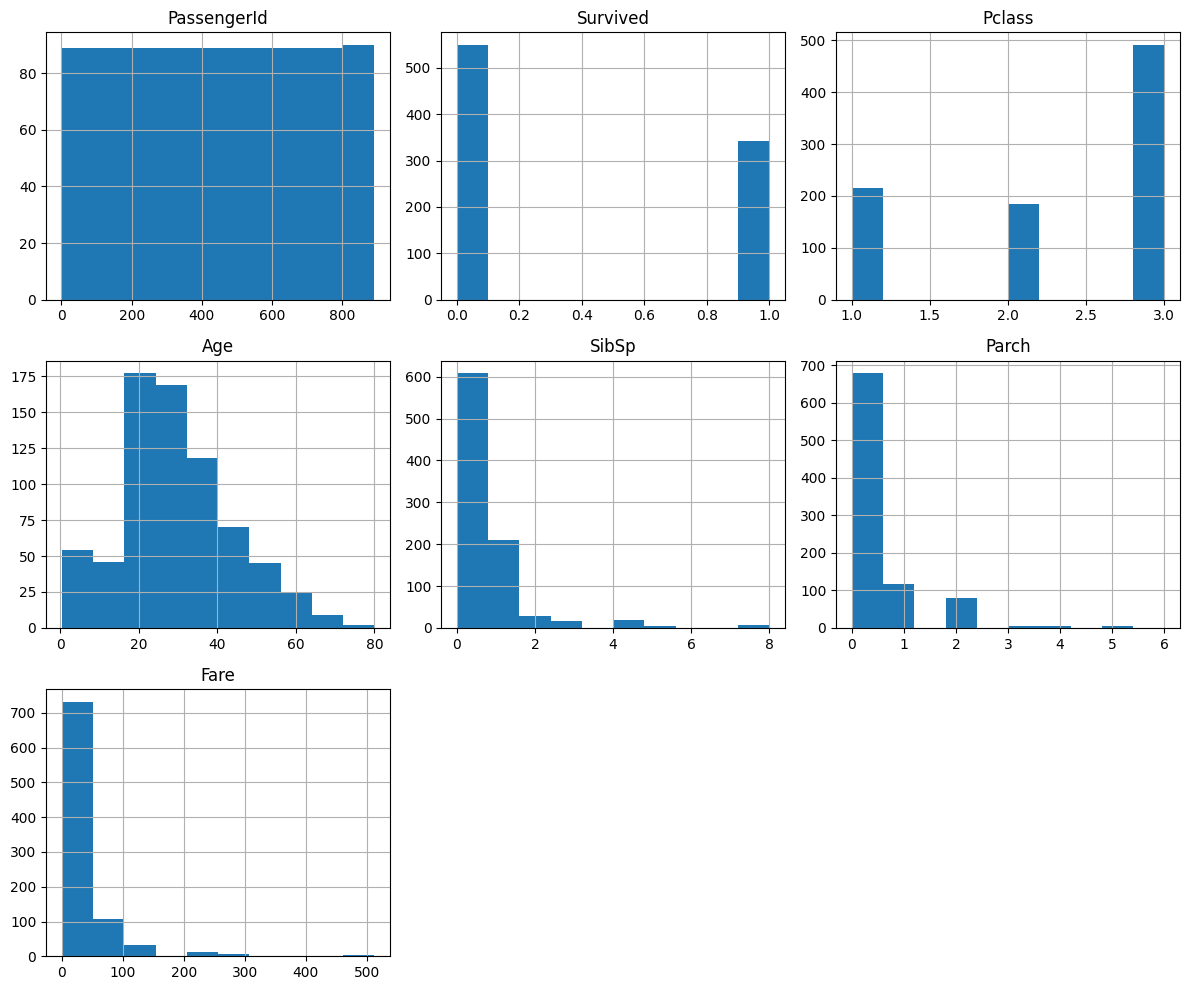

In [13]:
#Hstogram
import matplotlib.pyplot as plt
data.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

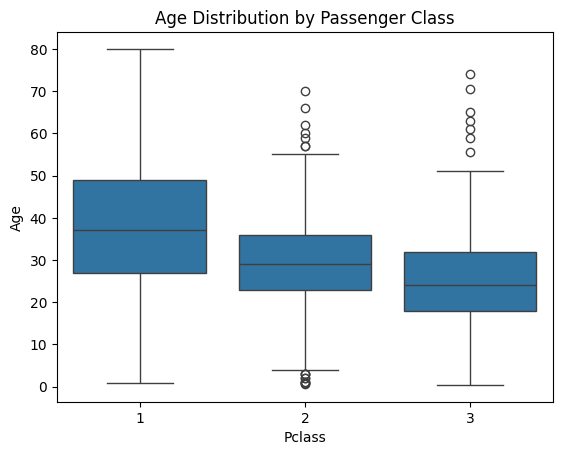

In [14]:
#boxplot
import seaborn as sns
sns.boxplot(x='Pclass', y='Age', data=data)
plt.title("Age Distribution by Passenger Class")
plt.show()


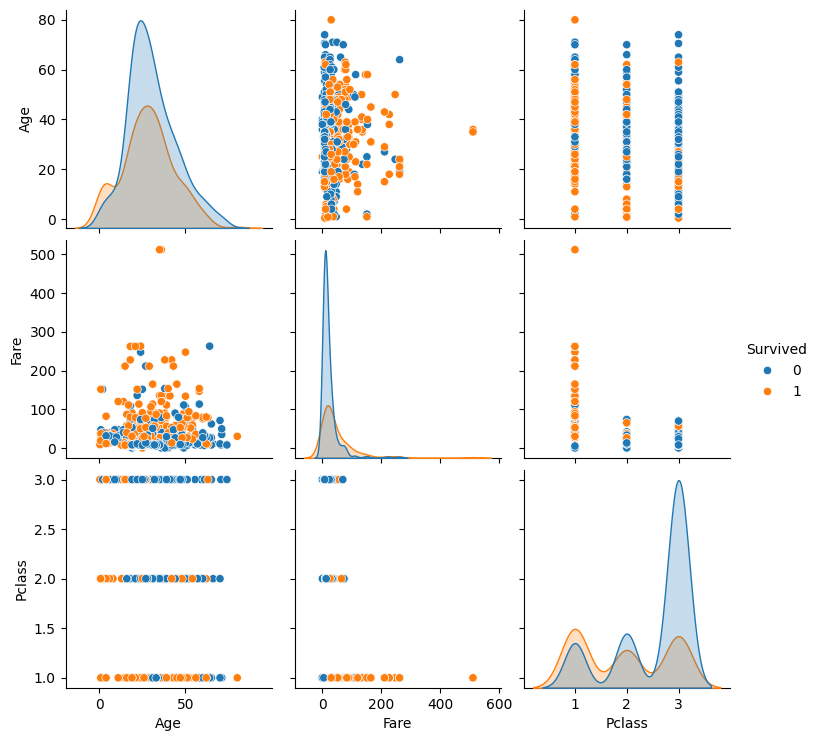

In [15]:
sns.pairplot(data[['Survived', 'Age', 'Fare', 'Pclass']], hue='Survived')


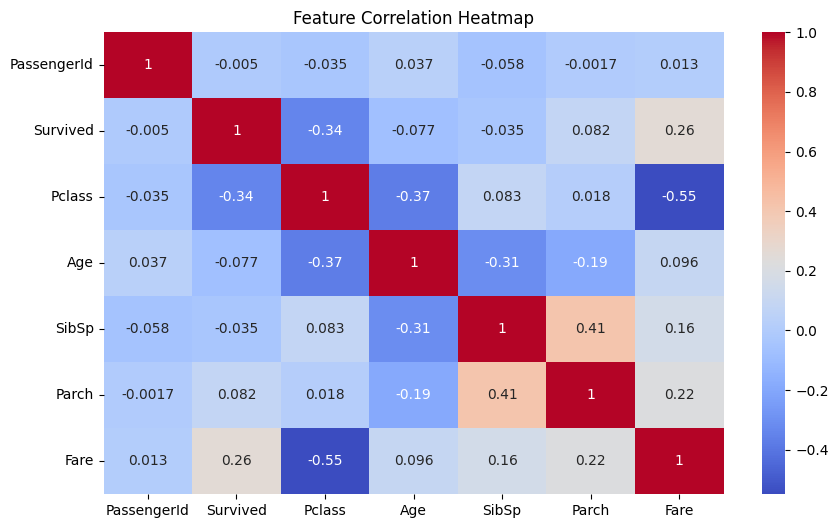

In [17]:
# Select only numeric columns for correlation
numeric_data = data.select_dtypes(include=['number'])

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


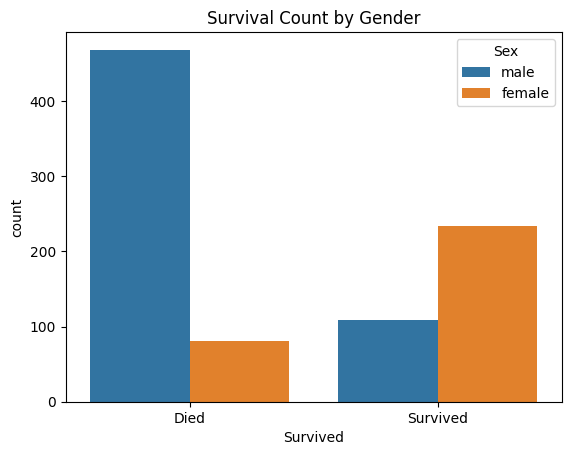

In [18]:
# Replace 0 with 'Died' and 1 with 'Survived'
data['Survived'] = data['Survived'].map({0: 'Died', 1: 'Survived'})

# Now plot 
sns.countplot(x='Survived', hue='Sex', data=data)
plt.title('Survival Count by Gender')
plt.show()
